# MAP challenge

In [4]:
# conda activate MAP2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import rampwf
import neurokit2 as nk

import problem

pd.set_option("display.max_columns", None)
print("sklearn", sklearn.__version__, ", need >= 1.6.0")
print("ramp", rampwf.__version__, ", need >= 0.7.0")

sklearn 1.6.0 , need >= 1.6.0
ramp 0.7.0 , need >= 0.7.0


## 1. Data Loading

In [2]:
X_df, y = problem.get_train_data()
X_df

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
300745,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.7044025157232704, 0.27358490566037735, 0.12...","[0.23573639982308714, 0.2038920831490491, 0.17...",val
300746,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.08440748440748441, 0.08773388773388774, 0.0...","[0.2519491177677472, 0.24743537135822732, 0.25...",val
300747,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.10831353919239906, 0.11211401425178148, 0.1...","[0.1249399327246516, 0.11965401249399327, 0.11...",val
300748,3590,p099038,74.0,M,m,NaN,NaN,NaN,10.0,"[0.06199460916442048, 0.0840071877807727, 0.10...","[0.8313827481577808, 0.8378846987429563, 0.838...",val


## 2. ECG feature extraction

In [11]:
# Random generator
rng = np.random.default_rng(seed=1)
NB_TRAIN_SAMPLES = X_df.shape[0]
SAMPLING_RATE = (
    len(X_df["ecg"].iloc[NB_TRAIN_SAMPLES - 1]) // 10
)  # nb of data points per second
print(SAMPLING_RATE)
plt.rcParams["figure.figsize"] = [20, 5]

125


Signal#123066


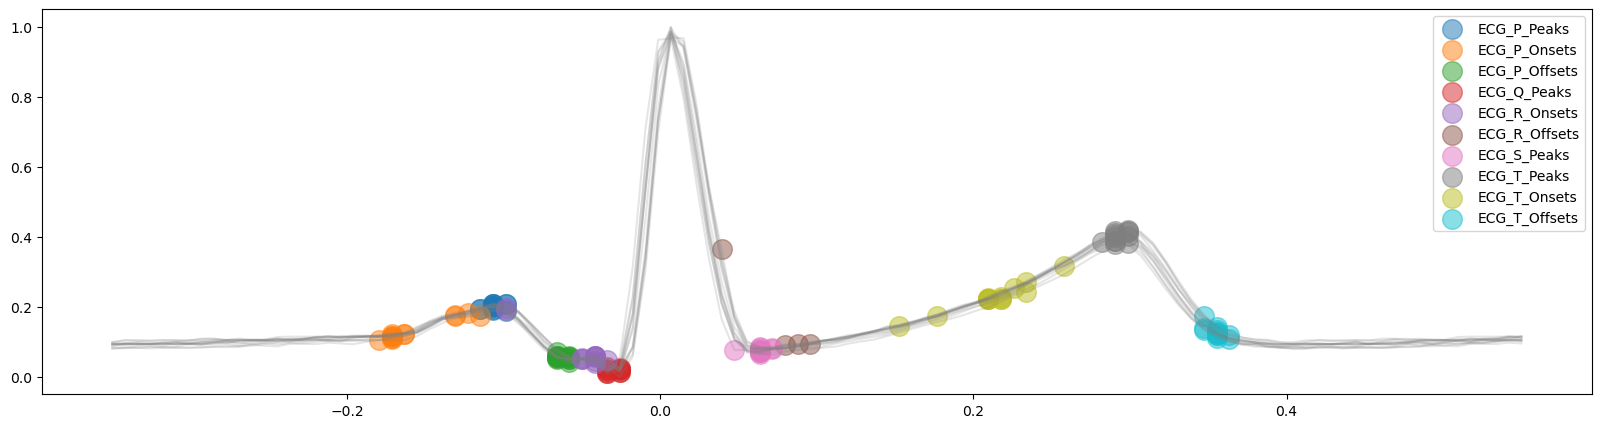

In [93]:
rand_idx = rng.choice(NB_TRAIN_SAMPLES)
ecg_signal = X_df["ecg"].iloc[rand_idx]
print(f"Signal#{rand_idx}")
signal, waves_peak = nk.ecg_delineate(
    ecg_signal, sampling_rate=SAMPLING_RATE, show=True, show_type="all"
)

In [77]:
waves_peak.keys()

dict_keys(['ECG_P_Peaks', 'ECG_P_Onsets', 'ECG_P_Offsets', 'ECG_Q_Peaks', 'ECG_R_Onsets', 'ECG_R_Offsets', 'ECG_S_Peaks', 'ECG_T_Peaks', 'ECG_T_Onsets', 'ECG_T_Offsets'])

In [96]:
ECG_DELTAS = {  # name : [end, start]
    "PR": ["ECG_R_Offsets", "ECG_P_Onsets"],
    "QS": ["ECG_S_Peaks", "ECG_Q_Peaks"],
    "RT": ["ECG_T_Offsets", "ECG_R_Onsets"],
    "TP": ["ECG_P_Offsets", "ECG_T_Onsets"],
    "PP": ["ECG_P_Peaks", "ECG_P_Onsets"],
    "TT": ["ECG_T_Peaks", "ECG_T_Onsets"],
}


def get_waves_len(waves_peak) -> dict[str : np.float64]:
    """Return the Duration of events in ECG with mean and std.
    - P, R, T waves.
    - P-R, R-T, T-P, Q-S deltas
    - heart rate"""
    val_dict = {}
    # Phase duration
    for wave_n in ["P", "R", "T"]:
        waves_len = np.array(waves_peak[f"ECG_{wave_n}_Offsets"]) - np.array(
            waves_peak[f"ECG_{wave_n}_Onsets"]
        )
        waves_len = waves_len[~np.isnan(waves_len)]
        val_dict[f"ECG_{wave_n}_Duration_mean"] = waves_len.mean()
        val_dict[f"ECG_{wave_n}_Duration_std"] = waves_len.std()

    # Delta between phases PR, peak QS, RT, TP

    for delta_name, [end, start] in ECG_DELTAS.items():
        delta_len = np.array(waves_peak[end]) - np.array(waves_peak[start])
        delta_len = delta_len[~np.isnan(delta_len)]
        val_dict[f"ECG_{delta_name}_delta_mean"] = delta_len.mean()
        val_dict[f"ECG_{delta_name}_delta_std"] = delta_len.std()

    # Heart rate
    # Should have use the R_peaks, but it is not computed in waves_peak, so use
    # Q_peaks instead.
    dfeet = np.diff(waves_peak["ECG_Q_Peaks"])
    dfeet = dfeet[~np.isnan(dfeet)]
    # Result in beats per minute
    dfeet = 60 / dfeet * SAMPLING_RATE

    val_dict["ECG_Heartrate_mean"] = dfeet.mean()
    val_dict["ECG_Heartrate_std"] = dfeet.std()

    return val_dict


def get_peak_stat_values(ecg_signal, waves_peak):
    val_dict = {}
    for peak, idx in waves_peak.items():
        idx = [x for x in idx if not np.isnan(x)]
        idx = np.array(idx, dtype=int)
        values = ecg_signal[idx]
        val_dict[f"{peak}_val_mean"] = values.mean()
        val_dict[f"{peak}val_std"] = values.std()
        # print(peak, ":", values.mean(), ",", values.std())
    return val_dict

In [98]:
get_waves_len(waves_peak)


{'ECG_P_Duration_mean': np.float64(11.615384615384615),
 'ECG_P_Duration_std': np.float64(2.646869312936193),
 'ECG_R_Duration_mean': np.float64(16.333333333333332),
 'ECG_R_Duration_std': np.float64(0.4714045207910317),
 'ECG_T_Duration_mean': np.float64(17.46153846153846),
 'ECG_T_Duration_std': np.float64(3.078845553259923),
 'ECG_PR_delta_mean': np.float64(26.25),
 'ECG_PR_delta_std': np.float64(4.710360920354193),
 'ECG_QS_delta_mean': np.float64(11.5),
 'ECG_QS_delta_std': np.float64(0.6454972243679028),
 'ECG_RT_delta_mean': np.float64(50.166666666666664),
 'ECG_RT_delta_std': np.float64(2.6404965862924765),
 'ECG_TP_delta_mean': np.float64(-34.0),
 'ECG_TP_delta_std': np.float64(3.2105595007244934),
 'ECG_PP_delta_mean': np.float64(6.230769230769231),
 'ECG_PP_delta_std': np.float64(2.7499327587260733),
 'ECG_TT_delta_mean': np.float64(9.846153846153847),
 'ECG_TT_delta_std': np.float64(3.254491661739412),
 'ECG_Heartrate_mean': np.float64(80.25853183393755),
 'ECG_Heartrate_st

In [99]:
get_waves_len(waves_peak)

{'ECG_P_Duration_mean': np.float64(11.615384615384615),
 'ECG_P_Duration_std': np.float64(2.646869312936193),
 'ECG_R_Duration_mean': np.float64(16.333333333333332),
 'ECG_R_Duration_std': np.float64(0.4714045207910317),
 'ECG_T_Duration_mean': np.float64(17.46153846153846),
 'ECG_T_Duration_std': np.float64(3.078845553259923),
 'ECG_PR_delta_mean': np.float64(26.25),
 'ECG_PR_delta_std': np.float64(4.710360920354193),
 'ECG_QS_delta_mean': np.float64(11.5),
 'ECG_QS_delta_std': np.float64(0.6454972243679028),
 'ECG_RT_delta_mean': np.float64(50.166666666666664),
 'ECG_RT_delta_std': np.float64(2.6404965862924765),
 'ECG_TP_delta_mean': np.float64(-34.0),
 'ECG_TP_delta_std': np.float64(3.2105595007244934),
 'ECG_PP_delta_mean': np.float64(6.230769230769231),
 'ECG_PP_delta_std': np.float64(2.7499327587260733),
 'ECG_TT_delta_mean': np.float64(9.846153846153847),
 'ECG_TT_delta_std': np.float64(3.254491661739412),
 'ECG_Heartrate_mean': np.float64(80.25853183393755),
 'ECG_Heartrate_st

In [102]:
def extract_ecg_features(one_ecg_as_list) -> pd.Series:
    """Extract relevant features from the ecg."""

    signal, waves_peak = nk.ecg_delineate(
        one_ecg_as_list, sampling_rate=SAMPLING_RATE
    )
    waves_len = get_waves_len(waves_peak)
    peak_val = get_peak_stat_values(one_ecg_as_list, waves_peak)
    ecg_features = {**waves_len, **peak_val}

    return pd.Series(ecg_features)


# Test
ecg_features_df = X_df["ecg"].iloc[100:200].apply(extract_ecg_features)
ecg_features_df

,ECG_P_Duration_mean,ECG_P_Duration_std,ECG_R_Duration_mean,ECG_R_Duration_std,ECG_T_Duration_mean,ECG_T_Duration_std,ECG_PR_delta_mean,ECG_PR_delta_std,ECG_QS_delta_mean,ECG_QS_delta_std,ECG_RT_delta_mean,ECG_RT_delta_std,ECG_TP_delta_mean,ECG_TP_delta_std,ECG_PP_delta_mean,ECG_PP_delta_std,ECG_TT_delta_mean,ECG_TT_delta_std,ECG_Heartrate_mean,ECG_Heartrate_std,ECG_P_Peaks_val_mean,ECG_P_Peaksval_std,ECG_P_Onsets_val_mean,ECG_P_Onsetsval_std,ECG_P_Offsets_val_mean,ECG_P_Offsetsval_std,ECG_Q_Peaks_val_mean,ECG_Q_Peaksval_std,ECG_R_Onsets_val_mean,ECG_R_Onsetsval_std,ECG_R_Offsets_val_mean,ECG_R_Offsetsval_std,ECG_S_Peaks_val_mean,ECG_S_Peaksval_std,ECG_T_Peaks_val_mean,ECG_T_Peaksval_std,ECG_T_Onsets_val_mean,ECG_T_Onsetsval_std,ECG_T_Offsets_val_mean,ECG_T_Offsetsval_std
100,20.357143,9.285989,28.583333,6.613853,5.133333,0.339935,52.214286,13.990704,26.285714,3.880879,37.750000,6.672393,-35.733333,4.739433,14.000000,6.824326,2.600000,0.489898,92.936288,6.425521,0.604832,0.136160,0.264926,0.096749,0.412120,0.076154,0.369723,0.068328,0.423730,0.123836,0.197339,0.052473,0.221561,0.082032,0.872406,0.063463,0.262278,0.086269,0.239070,0.075904
101,24.642857,6.171445,25.916667,5.648869,5.066667,0.249444,56.428571,9.131690,23.571429,3.063944,35.166667,5.161288,-35.785714,3.648455,16.571429,4.370588,2.400000,0.489898,93.155229,3.336894,0.649538,0.112641,0.141485,0.069137,0.357181,0.055908,0.315526,0.036128,0.353601,0.112693,0.120518,0.140617,0.088395,0.041863,0.911248,0.074877,0.178665,0.088933,0.131556,0.087622
102,14.800000,1.166190,21.666667,0.471405,15.300000,3.100000,30.900000,1.135782,9.555556,0.831479,61.666667,1.490712,-40.800000,3.155947,8.800000,1.249000,8.800000,2.959730,63.570681,0.847770,0.674079,0.035146,0.378994,0.029949,0.285916,0.041066,0.214344,0.043560,0.677059,0.033948,0.356242,0.064752,0.227251,0.053018,0.615406,0.044269,0.393819,0.085363,0.457326,0.052021
103,12.923077,9.474350,26.500000,3.774917,6.500000,5.151283,41.384615,15.770169,23.307692,4.546928,39.100000,6.252200,-33.307692,6.520791,8.000000,6.468860,3.428571,4.065786,92.985698,12.294794,0.464800,0.208848,0.219986,0.059589,0.255688,0.077940,0.210895,0.070864,0.278811,0.110674,0.123418,0.062488,0.080031,0.046336,0.859509,0.096011,0.199243,0.105827,0.159311,0.089104
104,9.818182,4.706247,16.900000,5.107837,8.800000,4.093898,33.500000,6.037384,11.500000,5.333854,36.700000,16.763353,-35.200000,9.897474,5.636364,2.900556,4.700000,2.685144,78.503567,40.638879,0.704104,0.079537,0.593228,0.135735,0.586599,0.131288,0.521339,0.160901,0.614201,0.086686,0.665656,0.098131,0.573265,0.131564,0.686047,0.092075,0.590415,0.137676,0.620759,0.126234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,6.307692,2.299987,17.500000,5.693564,8.076923,6.438604,27.307692,5.634845,12.833333,6.706133,40.416667,9.920167,-34.461538,8.372256,2.769231,1.309953,4.307692,4.647325,87.710654,23.445657,0.476071,0.076780,0.363582,0.067055,0.235550,0.092803,0.205272,0.089644,0.336641,0.091972,0.413232,0.124440,0.279727,0.085780,0.507048,0.102368,0.352022,0.103519,0.312325,0.115004
196,9.066667,8.940296,29.625000,5.677532,5.200000,0.400000,37.533333,13.850953,28.214286,2.335398,38.875000,5.372092,-32.733333,5.470730,5.266667,6.777086,2.333333,0.471405,91.541861,2.697837,0.437178,0.153469,0.306516,0.163634,0.324828,0.046203,0.287213,0.040388,0.348773,0.129608,0.105315,0.033202,0.085438,0.035538,0.903801,0.064595,0.216924,0.110092,0.122287,0.062853
197,19.000000,9.114092,30.076923,4.665117,5.066667,0.249444,51.466667,12.669473,26.928571,2.282364,39.307692,5.297091,-36.533333,4.302971,12.533333,7.069811,2.333333,0.471405,92.399075,2.539831,0.594899,0.164513,0.187330,0.152418,0.335009,0.043183,0.282287,0.027817,0.354426,0.147273,0.084268,0.121146,0.065418,0.042039,0.885894,0.077932,0.167100,0.103116,0.075588,0.042704
198,12.000000,9.179688,28.200000,9.516302,7.000000,4.939636,38.400000

In [103]:
ecg_features_df.describe()

,ECG_P_Duration_mean,ECG_P_Duration_std,ECG_R_Duration_mean,ECG_R_Duration_std,ECG_T_Duration_mean,ECG_T_Duration_std,ECG_PR_delta_mean,ECG_PR_delta_std,ECG_QS_delta_mean,ECG_QS_delta_std,ECG_RT_delta_mean,ECG_RT_delta_std,ECG_TP_delta_mean,ECG_TP_delta_std,ECG_PP_delta_mean,ECG_PP_delta_std,ECG_TT_delta_mean,ECG_TT_delta_std,ECG_Heartrate_mean,ECG_Heartrate_std,ECG_P_Peaks_val_mean,ECG_P_Peaksval_std,ECG_P_Onsets_val_mean,ECG_P_Onsetsval_std,ECG_P_Offsets_val_mean,ECG_P_Offsetsval_std,ECG_Q_Peaks_val_mean,ECG_Q_Peaksval_std,ECG_R_Onsets_val_mean,ECG_R_Onsetsval_std,ECG_R_Offsets_val_mean,ECG_R_Offsetsval_std,ECG_S_Peaks_val_mean,ECG_S_Peaksval_std,ECG_T_Peaks_val_mean,ECG_T_Peaksval_std,ECG_T_Onsets_val_mean,ECG_T_Onsetsval_std,ECG_T_Offsets_val_mean,ECG_T_Offsetsval_std
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,11.127243,4.067743,21.048552,4.940752,11.545727,3.613129,33.962656,6.193789,17.310456,4.040957,42.615766,7.218649,-32.213626,4.538454,6.097478,2.837906,6.245073,2.744149,87.584957,12.264646,0.537533,0.089497,0.344349,0.068001,0.323797,0.061260,0.278715,0.062658,0.411309,0.125663,0.282154,0.077892,0.210563,0.059322,0.719680,0.082134,0.306909,0.093629,0.265381,0.079480
std,5.563265,3.358967,5.695706,1.693580,6.655831,2.699341,10.136085,5.311330,7.848507,2.624935,7.812264,3.598212,3.637599,2.245724,4.233225,2.542511,3.954499,1.856822,8.541676,12.448641,0.110279,0.059629,0.110880,0.041361,0.127918,0.033372,0.122362,0.041181,0.099893,0.068012,0.153768,0.053947,0.134217,0.039545,0.161039,0.041919,0.113429,0.032147,0.146310,0.040624
min,3.000000,0.349927,12.000000,0.471405,4.600000,0.000000,24.777778,0.266469,7.923077,0.831479,24.818182,1.490712,-41.555556,0.832666,1.090909,0.257539,2.071429,0.257539,63.570681,0.847770,0.255304,0.005307,0.127760,0.005301,0.081297,0.006694,0.040794,0.005506,0.163879,0.005167,0.068928,0.014640,0.037453,0.008645,0.292644,0.022979,0.160124,0.028846,0.057344,0.020040
25%,6.983333,1.312935,16.262238,3.858330,5.321429,0.498648,26.160714,1.457113,9.576389,1.853086,36.925000,4.416267,-35.381494,2.821042,3.600427,0.907809,2.525000,0.500000,82.142360,2.868562,0.457601,0.037771,0.264691,0.031886,0.233165,0.038511,0.204126,0.032448,0.346067,0.069677,0.174850,0.037992,0.088504,0.034543,0.593898,0.051511,0.212274,0.073930,0.146664,0.046942
50%,10.613095,2.762188,18.828571,4.606105,8.233333,3.601064,29.426573,4.594072,15.630952,3.205429,40.369318,6.676580,-31.503497,4.320971,4.483333,1.508056,4.414286,2.956535,90.352420,6.000937,0.557803,0.077788,0.335562,0.058815,0.338281,0.051801,0.298399,0.049446,0.403519,0.119346,0.235143,0.055143,0.186992,0.046062,0.709329,0.074559,0.278982,0.089153,0.232671,0.075563
75%,12.187500,6.657275,25.983974,5.577217,19.358766,5.705832,37.750000,10.092452,25.310440,5.411203,50.564560,9.533072,-29.267857,5.490974,7.133333,4.771772,10.475000,4.077552,93.028081,19.216335,0.613534,0.130423,0.417163,0.094903,0.409435,0.080264,0.363094,0.089731,0.478737,0.172219,0.390656,0.109020,0.304394,0.072216,0.881781,0.105718,0.391331,0.108980,0.359898,0.106122
max,25.600000,12.079668,32.857143,11.021444,23.214286,9.439674,59.666667,18.029361,30.000000,14.269594,61.666667,16.763353,-23.153846,11.662797,17.600000,8.897661,13.071429,6.677990,110.364160,49.851353,0.734250,0.229782,0.663808,0.178784,0.610816,0.154856,0.543119,0.176353,0.677059,0.260390,0.665656,0.261615,0.606328,0.216218,0.947133,0.211759,0.631245,0.230427,0.638733,0.199474


In [101]:
signal

,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1245,0,0,0,0,0,0,0,0,0,0
1246,0,0,0,0,0,0,0,0,0,0
1247,0,0,0,0,0,0,0,0,0,0
1248,0,0,0,0,0,0,0,0,0,0


# 3. PPG feature extraction